In [ ]:

# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import folium
from folium import FeatureGroup, LayerControl, GeoJson
from pyproj import Transformer
from shapely.geometry import shape, mapping, box
from shapely.ops import unary_union

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ── Configuration ─────────────────────────────────────────────────────────────
# Sectors to analyse: name → list of NUMSECTEUR IDs that form the area
SECTORS = {
    "Pontaise": [1503],
    "Prélaz":   [301, 304],
}

IOU_THRESHOLD    = 0.30   # minimum IoU to call two buildings the same
OFFSET_THRESHOLD = 3.0    # metres – apply correction if median shift > this
BUFFER_M         = 4.0    # buffer radius (m) drawn around 1945 buildings

BASE = os.path.dirname(os.path.abspath("building_evolution.ipynb"))

SIEGFRIED_YEARS = [1873, 1875, 1889, 1894, 1926, 1928, 1934, 1945]  # 1925 excluded (empty)

SIEGFRIED_DIR = os.path.join(BASE, "Siegfried")
SECTEUR_SHP   = os.path.join(BASE, "secteurs_stat", "Secteurs statistiques.shp")

print("Imports OK")
print(f"Sectors: {SECTORS}")
print(f"Siegfried years: {SIEGFRIED_YEARS}")


Imports OK
Sectors: {'Pontaise': [1503], 'Prélaz': [301, 304]}
Siegfried years: [1873, 1875, 1889, 1894, 1926, 1928, 1934, 1945]


In [ ]:

# ── Cell 2: Load secteurs shapefile ──────────────────────────────────────────
secteurs = gpd.read_file(SECTEUR_SHP)
print("Secteurs CRS:", secteurs.crs)
print("Columns:", list(secteurs.columns))
print("Total sectors:", len(secteurs))
print(secteurs.head(3))


Secteurs CRS: EPSG:2056
Columns: ['NUMSECTEUR', 'NOMSECTEUR', 'NUMQUARTIE', 'NOMQUARTIE', 'geometry']
Total sectors: 84
   NUMSECTEUR    NOMSECTEUR  NUMQUARTIE      NOMQUARTIE  \
0        1001     Le Vallon          10  Vallon/Béthusy   
1        1002      Hôpitaux          10  Vallon/Béthusy   
2        1003  Victor-Ruffy          10  Vallon/Béthusy   

                                            geometry  
0  POLYGON ((2538843.933 1153219.209, 2538833.704...  
1  POLYGON ((2539134.715 1152905.921, 2539134.137...  
2  POLYGON ((2539354.077 1153361.701, 2539360.629...  


In [19]:

# ── Cell 3: Extract sector polygons ──────────────────────────────────────────
# Find the numeric sector-ID column automatically
id_col = None
for col in secteurs.columns:
    if col == "geometry":
        continue
    # Check if any of our IDs appear in this column
    all_ids = [str(sid) for ids in SECTORS.values() for sid in ids]
    if any(secteurs[col].astype(str).str.contains(sid).any() for sid in all_ids):
        id_col = col
        print(f"Sector ID column: '{id_col}'")
        break

if id_col is None:
    raise ValueError("Could not find a column containing the sector IDs. Available columns: "
                     + str([c for c in secteurs.columns if c != "geometry"]))

# Build one validated polygon per named area (union of all sub-sectors)
sector_geoms   = {}   # name → Shapely geom in EPSG:2056
sector_valids  = {}   # name → make_valid version

# Import here so it's available in downstream cells too
from shapely.validation import make_valid
from shapely.geometry import GeometryCollection as ShapelyCollection
import shapely

def extract_polygons(geom):
    if geom is None or geom.is_empty:
        return None
    if geom.geom_type in ("Polygon", "MultiPolygon"):
        return geom
    if "Collection" in geom.geom_type:
        parts = [g for g in geom.geoms if g.geom_type in ("Polygon", "MultiPolygon")]
        return unary_union(parts) if parts else None
    return None

for name, ids in SECTORS.items():
    rows = secteurs[secteurs[id_col].astype(str).isin([str(i) for i in ids])]
    print(f"\n{name}: found {len(rows)} sector row(s) for IDs {ids}")
    geom = rows.union_all() if hasattr(rows, "union_all") else unary_union(rows.geometry)

    # Reproject to EPSG:2056 if needed
    if secteurs.crs and secteurs.crs.to_epsg() != 2056:
        tmp = gpd.GeoDataFrame(geometry=[geom], crs=secteurs.crs).to_crs("EPSG:2056")
        geom = tmp.geometry.iloc[0]

    sector_geoms[name]  = geom
    sector_valids[name] = extract_polygons(make_valid(geom)) or geom
    print(f"  Bounds (EPSG:2056): {geom.bounds}")


Sector ID column: 'NUMSECTEUR'

Pontaise: found 1 sector row(s) for IDs [1503]
  Bounds (EPSG:2056): (2537733.8996312674, 1153240.4794589714, 2538181.3820408788, 1153899.2274044657)

Prélaz: found 2 sector row(s) for IDs [301, 304]
  Bounds (EPSG:2056): (2535944.6411426654, 1152722.2739346966, 2537553.2922957293, 1153407.6199791816)


In [4]:

# ── Cell 4: Load all Siegfried shapefiles ────────────────────────────────────
siegfried_raw = {}
for year in SIEGFRIED_YEARS:
    path = os.path.join(SIEGFRIED_DIR, f"25_{year}.shp")
    gdf = gpd.read_file(path)
    siegfried_raw[year] = gdf
    print(f"{year}: {len(gdf)} features | CRS: {gdf.crs} | columns: {list(gdf.columns)}")

print("\nGeometry types sample (1945):", siegfried_raw[1945].geom_type.value_counts().to_dict())


1873: 10882 features | CRS: EPSG:21781 | columns: ['FID', 'geometry']
1875: 12257 features | CRS: EPSG:21781 | columns: ['FID', 'geometry']
1889: 46212 features | CRS: EPSG:21781 | columns: ['FID', 'geometry']


C:\Users\aymer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\pyogrio\raw.py:200: RuntimeWarning: c:\School\EPFL\HUM450\HUM450-Quartiers\Siegfried\25_1894.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(
C:\Users\aymer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\pyogrio\raw.py:200: RuntimeWarning: c:\School\EPFL\HUM450\HUM450-Quartiers\Siegfried\25_1925.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


1894: 51733 features | CRS: EPSG:21781 | columns: ['FID', 'geometry']
1925: 37206 features | CRS: EPSG:21781 | columns: ['FID', 'geometry']
1926: 31040 features | CRS: EPSG:21781 | columns: ['FID', 'geometry']


C:\Users\aymer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\pyogrio\raw.py:200: RuntimeWarning: c:\School\EPFL\HUM450\HUM450-Quartiers\Siegfried\25_1928.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


1928: 159734 features | CRS: EPSG:21781 | columns: ['FID', 'geometry']
1934: 58364 features | CRS: EPSG:21781 | columns: ['FID', 'geometry']
1945: 182344 features | CRS: EPSG:21781 | columns: ['FID', 'geometry']

Geometry types sample (1945): {'Polygon': 182344}


In [20]:

# ── Cell 5: Reproject to EPSG:2056, clip to each sector ──────────────────────
# siegfried[sector_name][year] → GeoDataFrame of buildings in that sector+year

siegfried = {name: {} for name in SECTORS}

for year in SIEGFRIED_YEARS:
    raw = siegfried_raw[year].copy()

    # Reproject raw data to EPSG:2056 once per year
    if raw.crs is None:
        raw = raw.set_crs("EPSG:21781")
    if raw.crs.to_epsg() != 2056:
        raw = raw.to_crs("EPSG:2056")

    # Fix invalid geometries and drop non-polygon results
    raw["geometry"] = raw.geometry.apply(lambda g: extract_polygons(make_valid(g)))
    raw = raw[raw.geometry.notna() & ~raw.geometry.is_empty].copy()

    for name, sv in sector_valids.items():
        candidates = raw[raw.geometry.intersects(sv)].copy()
        candidates["geometry"] = candidates.geometry.apply(
            lambda g: extract_polygons(make_valid(g).intersection(sv))
        )
        candidates = candidates[candidates.geometry.notna() & ~candidates.geometry.is_empty].copy()
        candidates = candidates.reset_index(drop=True)
        siegfried[name][year] = candidates

for name in SECTORS:
    print(f"\n── {name} ──")
    for year in SIEGFRIED_YEARS:
        print(f"  {year}: {len(siegfried[name][year])} buildings")



── Pontaise ──
  1873: 13 buildings
  1875: 13 buildings
  1889: 50 buildings
  1894: 71 buildings
  1926: 85 buildings
  1928: 112 buildings
  1934: 107 buildings
  1945: 111 buildings

── Prélaz ──
  1873: 36 buildings
  1875: 36 buildings
  1889: 47 buildings
  1894: 63 buildings
  1926: 125 buildings
  1928: 147 buildings
  1934: 145 buildings
  1945: 148 buildings


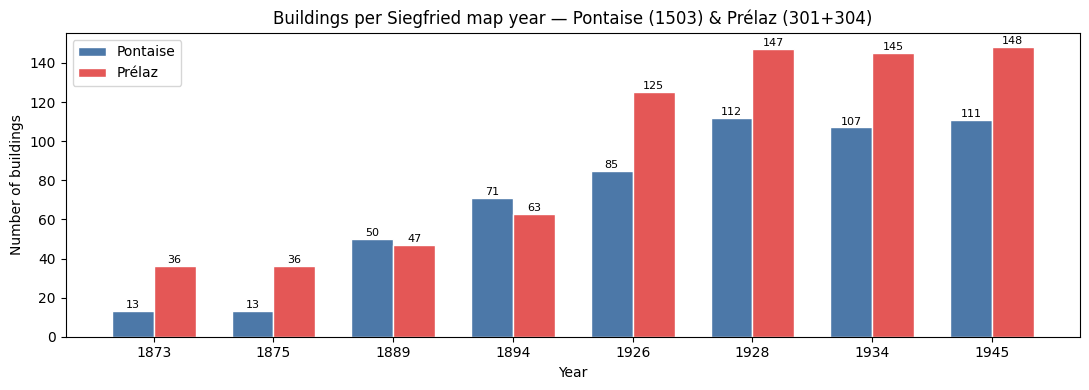

In [21]:

# ── Building count per year (both sectors) ───────────────────────────────────
import matplotlib.pyplot as plt

x = np.arange(len(SIEGFRIED_YEARS))
width = 0.35
sector_names = list(SECTORS.keys())
sector_colours = {"Pontaise": "#4c78a8", "Prélaz": "#e45756"}

fig, ax = plt.subplots(figsize=(11, 4))
for i, name in enumerate(sector_names):
    counts = [len(siegfried[name][y]) for y in SIEGFRIED_YEARS]
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, counts, width, label=name,
                  color=sector_colours.get(name, "#888"), edgecolor="white")
    for bar, v in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                str(v), ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([str(y) for y in SIEGFRIED_YEARS])
ax.set_xlabel("Year")
ax.set_ylabel("Number of buildings")
ax.set_title("Buildings per Siegfried map year — Pontaise (1503) & Prélaz (301+304)")
ax.legend()
plt.tight_layout()
plt.show()


In [22]:

# ── Cell 6: Assign building IDs & match buildings across years via IoU ────────

def compute_iou(a, b):
    try:
        inter = a.intersection(b).area
        if inter == 0:
            return 0.0
        union = a.union(b).area
        return inter / union if union > 0 else 0.0
    except Exception:
        return 0.0

# ref[sector_name] → 1945 GeoDataFrame with stable building_id
ref = {}

for name in SECTORS:
    ref_gdf = siegfried[name][1945].copy()
    prefix = name[:3].upper()   # e.g. PON, PRÉ
    ref_gdf["building_id"] = [f"{prefix}{i:04d}" for i in range(len(ref_gdf))]
    ref_gdf["year"]   = 1945
    ref_gdf["status"] = "reference"
    siegfried[name][1945] = ref_gdf
    ref[name] = ref_gdf

    print(f"\n── {name}: matching older years to 1945 ──")
    for year in SIEGFRIED_YEARS[:-1]:
        gdf = siegfried[name][year].copy()
        gdf["building_id"] = None
        gdf["year"]   = year
        gdf["status"] = "demolished"

        ref_list = list(ref_gdf.iterrows())
        for i, row in gdf.iterrows():
            best_iou, best_bid = 0.0, None
            for _, rr in ref_list:
                iou = compute_iou(row.geometry, rr.geometry)
                if iou > best_iou:
                    best_iou, best_bid = iou, rr["building_id"]
            if best_iou >= IOU_THRESHOLD:
                gdf.at[i, "building_id"] = best_bid
                gdf.at[i, "status"] = "persistent"

        siegfried[name][year] = gdf
        n_p = (gdf["status"] == "persistent").sum()
        n_d = (gdf["status"] == "demolished").sum()
        print(f"  {year}: {n_p} matched | {n_d} demolished")

    # Mark 1945 buildings that never appeared in any older year
    matched_ids = set()
    for year in SIEGFRIED_YEARS[:-1]:
        matched_ids |= set(siegfried[name][year].dropna(subset=["building_id"])["building_id"])

    ref_gdf["status"] = ref_gdf["building_id"].apply(
        lambda bid: "persistent" if bid in matched_ids else "new"
    )
    siegfried[name][1945] = ref_gdf
    ref[name] = ref_gdf
    n_new  = (ref_gdf["status"] == "new").sum()
    n_pers = (ref_gdf["status"] == "persistent").sum()
    print(f"  1945: {n_pers} persistent | {n_new} new")



── Pontaise: matching older years to 1945 ──
  1873: 2 matched | 11 demolished
  1875: 0 matched | 13 demolished
  1889: 4 matched | 46 demolished
  1894: 2 matched | 69 demolished
  1926: 4 matched | 81 demolished
  1928: 95 matched | 17 demolished
  1934: 93 matched | 14 demolished
  1945: 100 persistent | 11 new

── Prélaz: matching older years to 1945 ──
  1873: 1 matched | 35 demolished
  1875: 1 matched | 35 demolished
  1889: 2 matched | 45 demolished
  1894: 1 matched | 62 demolished
  1926: 20 matched | 105 demolished
  1928: 125 matched | 22 demolished
  1934: 125 matched | 20 demolished
  1945: 135 persistent | 13 new


In [23]:

# ── Cell 7: Timeline summary tables ──────────────────────────────────────────
timelines = {}

for name in SECTORS:
    all_ids = sorted(set(ref[name]["building_id"]))
    rows = []
    for bid in all_ids:
        row = {"building_id": bid}
        for year in SIEGFRIED_YEARS:
            gdf = siegfried[name][year]
            match = gdf[gdf["building_id"] == bid]
            row[str(year)] = match.iloc[0]["status"] if len(match) > 0 else "absent"
        rows.append(row)

    tl = pd.DataFrame(rows).set_index("building_id")
    timelines[name] = tl
    print(f"\n══ {name} ══")
    print(tl.to_string())

    years_str = [str(y) for y in SIEGFRIED_YEARS]
    print(f"\n  Change counts ({name}):")
    for i in range(1, len(years_str)):
        prev, curr = years_str[i-1], years_str[i]
        appeared    = ((tl[prev] == "absent") & (tl[curr] != "absent")).sum()
        disappeared = ((tl[prev] != "absent") & (tl[curr] == "absent")).sum()
        print(f"    {prev}→{curr}: +{appeared} built, -{disappeared} demolished")



══ Pontaise ══
                   1873    1875        1889        1894        1926        1928        1934        1945
building_id                                                                                            
PON0000          absent  absent      absent      absent      absent  persistent  persistent  persistent
PON0001          absent  absent      absent      absent      absent  persistent  persistent  persistent
PON0002          absent  absent      absent      absent      absent  persistent  persistent  persistent
PON0003          absent  absent      absent      absent      absent      absent  persistent  persistent
PON0004          absent  absent      absent      absent      absent  persistent  persistent  persistent
PON0005          absent  absent      absent      absent      absent  persistent  persistent  persistent
PON0006          absent  absent      absent      absent      absent  persistent  persistent  persistent
PON0007          absent  absent      absent     

In [25]:

# ── Cell 8: Offset detection & correction ────────────────────────────────────
from shapely.affinity import translate

offsets            = {name: {} for name in SECTORS}
siegfried_corrected = {name: {} for name in SECTORS}

for name in SECTORS:
    # Plain dict: building_id → centroid Point
    ref_centroids = {
        row["building_id"]: row.geometry.centroid
        for _, row in ref[name].iterrows()
        if row["building_id"] is not None
    }
    print(f"\n── {name} ({len(ref_centroids)} reference buildings) ──")

    for year in SIEGFRIED_YEARS[:-1]:
        gdf     = siegfried[name][year].copy()
        matched = gdf[gdf["status"] == "persistent"].copy()

        if len(matched) == 0:
            print(f"  {year}: no matched buildings – no offset computed.")
            offsets[name][year] = (0.0, 0.0)
            siegfried_corrected[name][year] = gdf
            continue

        dxs, dys = [], []
        for _, row in matched.iterrows():
            bid = row["building_id"]
            if bid not in ref_centroids:
                continue
            old_c = row.geometry.centroid
            new_c = ref_centroids[bid]
            dxs.append(new_c.x - old_c.x)
            dys.append(new_c.y - old_c.y)

        if not dxs:
            print(f"  {year}: no valid centroid pairs – skipping.")
            offsets[name][year] = (0.0, 0.0)
            siegfried_corrected[name][year] = gdf
            continue

        mdx = float(np.median(dxs))
        mdy = float(np.median(dys))
        mag = (mdx**2 + mdy**2) ** 0.5

        if mag > OFFSET_THRESHOLD:
            print(f"  {year}: offset {mag:.1f} m (dx={mdx:.1f}, dy={mdy:.1f}) → correcting")
            gdf["geometry"] = gdf.geometry.apply(lambda g: translate(g, xoff=mdx, yoff=mdy))
            offsets[name][year] = (mdx, mdy)
        else:
            print(f"  {year}: offset {mag:.2f} m (below threshold – no correction)")
            offsets[name][year] = (0.0, 0.0)

        siegfried_corrected[name][year] = gdf

    siegfried_corrected[name][1945] = siegfried[name][1945].copy()
    offsets[name][1945] = (0.0, 0.0)

print("\nOffset correction complete.")



── Pontaise (111 reference buildings) ──
  1873: offset 2.7 m (dx=2.3, dy=1.4) → correcting
  1875: no matched buildings – no offset computed.
  1889: offset 4.1 m (dx=1.6, dy=-3.7) → correcting
  1894: offset 4.7 m (dx=0.2, dy=-4.7) → correcting
  1926: offset 5.3 m (dx=0.3, dy=-5.3) → correcting
  1928: offset 0.33 m (below threshold – no correction)
  1934: offset 0.87 m (below threshold – no correction)

── Prélaz (148 reference buildings) ──
  1873: offset 5.6 m (dx=5.3, dy=1.7) → correcting
  1875: offset 5.3 m (dx=4.7, dy=2.4) → correcting
  1889: offset 1.07 m (below threshold – no correction)
  1894: offset 2.1 m (dx=1.4, dy=-1.6) → correcting
  1926: offset 3.0 m (dx=-1.7, dy=2.4) → correcting
  1928: offset 0.21 m (below threshold – no correction)
  1934: offset 0.44 m (below threshold – no correction)

Offset correction complete.


In [26]:

# ── Cell 9: Build Folium interactive map ─────────────────────────────────────
t_inv = Transformer.from_crs("EPSG:2056", "EPSG:4326", always_xy=True)

def geom_to_geojson_wgs84(geom):
    if geom is None or geom.is_empty:
        return None
    if geom.geom_type == "Polygon":
        polys = [geom]
    elif geom.geom_type == "MultiPolygon":
        polys = list(geom.geoms)
    else:
        return None
    coords_list = []
    for poly in polys:
        exterior = [[*(t_inv.transform(x, y))] for x, y in poly.exterior.coords]
        # t_inv returns (lon, lat) – GeoJSON wants [lon, lat]
        coords_list.append([exterior])
    if len(coords_list) == 1:
        return {"type": "Polygon", "coordinates": coords_list[0]}
    return {"type": "MultiPolygon", "coordinates": coords_list}

# Map centre = centroid of union of all sector geometries
all_geom_union = unary_union(list(sector_geoms.values()))
cx, cy = all_geom_union.centroid.x, all_geom_union.centroid.y
clon, clat = t_inv.transform(cx, cy)

m = folium.Map(location=[clat, clon], zoom_start=15, tiles="CartoDB positron")

# ── Sector boundary colours ───────────────────────────────────────────────────
SECTOR_COLOURS = {"Pontaise": "#1f77b4", "Prélaz": "#9467bd"}

# ── Sector boundaries ─────────────────────────────────────────────────────────
for name, geom in sector_geoms.items():
    fg = FeatureGroup(name=f"{name} boundary", show=True)
    gj = geom_to_geojson_wgs84(geom)
    if gj:
        sc = SECTOR_COLOURS[name]
        folium.GeoJson(
            {"type": "Feature", "geometry": gj, "properties": {}},
            style_function=lambda _, c=sc: {
                "color": c, "weight": 3, "fillOpacity": 0.07, "fillColor": c
            },
            tooltip=f"{name} boundary",
        ).add_to(fg)
    fg.add_to(m)

# ── 1945 buffer outlines ──────────────────────────────────────────────────────
for name in SECTORS:
    fg = FeatureGroup(name=f"{name} – 1945 buffer outlines", show=True)
    for _, row in siegfried_corrected[name][1945].iterrows():
        try:
            buf_gj = geom_to_geojson_wgs84(row.geometry.buffer(BUFFER_M))
            if buf_gj:
                folium.GeoJson(
                    {"type": "Feature", "geometry": buf_gj, "properties": {}},
                    style_function=lambda _: {
                        "color": "#555", "weight": 1.2, "fillOpacity": 0, "dashArray": "5,5"
                    },
                ).add_to(fg)
        except Exception:
            pass
    fg.add_to(m)

# ── Year colour palette ───────────────────────────────────────────────────────
YEAR_COLOURS = {
    1873: "#e6550d", 1875: "#fd8d3c", 1889: "#fdae6b", 1894: "#fdd0a2",
    1926: "#a1d99b", 1928: "#74c476", 1934: "#41ab5d", 1945: "#2ca02c",
}
DEMOLISHED_COLOUR = "#d62728"
NEW_COLOUR        = "#17becf"

# ── One FeatureGroup per sector × year ───────────────────────────────────────
for name in SECTORS:
    for year in SIEGFRIED_YEARS:
        gdf = siegfried_corrected[name][year]
        fg  = FeatureGroup(name=f"{name} – {year}", show=(year == 1945))

        for _, row in gdf.iterrows():
            status = row.get("status", "unknown")
            bid    = row.get("building_id", "—")

            if status == "persistent":
                fc = YEAR_COLOURS.get(year, "#888")
            elif status == "demolished":
                fc = DEMOLISHED_COLOUR
            elif status == "new":
                fc = NEW_COLOUR
            else:
                fc = YEAR_COLOURS.get(1945, "#2ca02c")  # reference = 1945 colour

            gj = geom_to_geojson_wgs84(row.geometry)
            if not gj:
                continue

            dx, dy = offsets[name].get(year, (0.0, 0.0))
            corr_note = (f"Correction: dx={dx:.1f}m dy={dy:.1f}m"
                         if abs(dx) > 0.01 or abs(dy) > 0.01 else "No correction")

            folium.GeoJson(
                {"type": "Feature", "geometry": gj, "properties": {}},
                style_function=lambda _, c=fc: {
                    "fillColor": c, "color": c, "weight": 1.5, "fillOpacity": 0.6
                },
                tooltip=folium.Tooltip(
                    f"<b>{name} – {year}</b><br>"
                    f"<b>ID:</b> {bid}<br>"
                    f"<b>Status:</b> {status}<br>"
                    f"<b>Georef:</b> {corr_note}"
                ),
            ).add_to(fg)

        fg.add_to(m)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_html = """
<div style="
    position:fixed;bottom:40px;left:40px;z-index:1000;
    background:white;padding:12px 16px;border-radius:8px;
    border:1px solid #ccc;font-size:13px;line-height:1.8;
    box-shadow:2px 2px 6px rgba(0,0,0,.3)">
  <b>Building status</b><br>
  <span style="color:#2ca02c">&#9632;</span> Persistent (also in older maps)<br>
  <span style="color:#17becf">&#9632;</span> New (first appears in 1945)<br>
  <span style="color:#d62728">&#9632;</span> Demolished (absent from 1945)<br>
  <span style="color:#555">&#9632;</span> 1945 buffer outline (3 m)<br>
  <hr style="margin:4px 0">
  <b>Year gradient (persistent)</b><br>
  <span style="color:#e6550d">&#9632;</span> 1873 &nbsp;
  <span style="color:#fdae6b">&#9632;</span> 1889 &nbsp;
  <span style="color:#a1d99b">&#9632;</span> 1926 &nbsp;
  <span style="color:#2ca02c">&#9632;</span> 1945<br>
  <hr style="margin:4px 0">
  <b>Sector boundaries</b><br>
  <span style="color:#1f77b4">&#9632;</span> Pontaise (1503) &nbsp;
  <span style="color:#9467bd">&#9632;</span> Prélaz (301+304)
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))
LayerControl(collapsed=False).add_to(m)
print("Map built.")
m


Map built.


In [27]:

# ── Cell 10: Save map to HTML ─────────────────────────────────────────────────
output_path = os.path.join(BASE, "building_evolution.html")
m.save(output_path)
print(f"Map saved to: {output_path}")


Map saved to: c:\School\EPFL\HUM450\HUM450-Quartiers\building_evolution.html
